<div style="text-align: center;">

# Social Network Analysis (CS342) | Assignment 12

## **Graph Neural Networks**

---

**Student Name:** *Naishadh Rana*

**Roll No:** U23CS014

---

</div>

## Objective

To understand Graph Neural Networks (GNNs) by implementing one on a simple molecular graph dataset.

**Tasks:**
1. Install and configure PyTorch Geometric and RDKit
2. Load and explore the ESOL (water-solubility) dataset from MoleculeNet
3. Visualise molecules as graphs using RDKit
4. Build a GCN-based Graph Neural Network for graph-level regression
5. Train the model for 1500 epochs and plot the training loss curve
6. Evaluate the model on the test set

**Tools:** `torch`, `torch_geometric`, `rdkit`, `matplotlib`

## 1 – Environment Setup

Install PyTorch Geometric and RDKit. If running locally and these are already installed, the cells below will finish instantly.

In [11]:
import torch
print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")

try:
    import torch_geometric
    print(f"PyG version     : {torch_geometric.__version__}")
except ImportError:
    !pip install torch-geometric
    import torch_geometric
    print(f"PyG version     : {torch_geometric.__version__}")

try:
    import rdkit
    print(f"RDKit version   : {rdkit.__version__}")
except ImportError:
    !pip install rdkit
    import rdkit
    print(f"RDKit version   : {rdkit.__version__}")

PyTorch version : 2.10.0
CUDA available  : False
PyG version     : 2.7.0
RDKit version   : 2026.03.1


## 2 – Load and Explore the ESOL Dataset

ESOL contains water-solubility data for 1128 compounds, encoded as SMILES strings. Each molecule becomes a graph where **atoms → nodes** and **bonds → edges**. The regression target *y* is the measured log-solubility.

In [12]:
from torch_geometric.datasets import MoleculeNet

data = MoleculeNet(root=".", name="ESOL")

print(f"Dataset            : {data}")
print(f"Number of graphs   : {len(data)}")
print(f"Number of features : {data.num_features}")
print(f"Number of classes  : {data.num_classes}")

Dataset            : ESOL(1128)
Number of graphs   : 1128
Number of features : 9
Number of classes  : 734


/Users/naish/Desktop/College/Sem6/.venv/lib/python3.12/site-packages/torch_geometric/data/in_memory_dataset.py:91: UserWarning: Found floating-point labels while calling `dataset.num_classes`. Returning the number of unique elements. Please make sure that this is expected before proceeding.
  return self._infer_num_classes(self._data.y)


In [13]:
sample = data[0]

print(f"Sample graph       : {sample}")
print(f"SMILES             : {sample['smiles']}")
print(f"Nodes (atoms)      : {sample.num_nodes}")
print(f"Edges (bonds)      : {sample.num_edges}")
print(f"Node-feature dim   : {sample.num_node_features}")
print(f"Target (y)         : {sample.y.item():.4f}")
print(f"Has isolated nodes : {sample.has_isolated_nodes()}")
print(f"Has self-loops     : {sample.has_self_loops()}")
print(f"Is undirected      : {sample.is_undirected()}")

Sample graph       : Data(x=[32, 9], edge_index=[2, 68], edge_attr=[68, 3], smiles='OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)C(O)C3O ', y=[1, 1])
SMILES             : OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)C(O)C3O 
Nodes (atoms)      : 32
Edges (bonds)      : 68
Node-feature dim   : 9
Target (y)         : -0.7700
Has isolated nodes : False
Has self-loops     : False
Is undirected      : True


## 3 – Visualise Molecules with RDKit

Convert SMILES strings back to molecular graphs and render them.

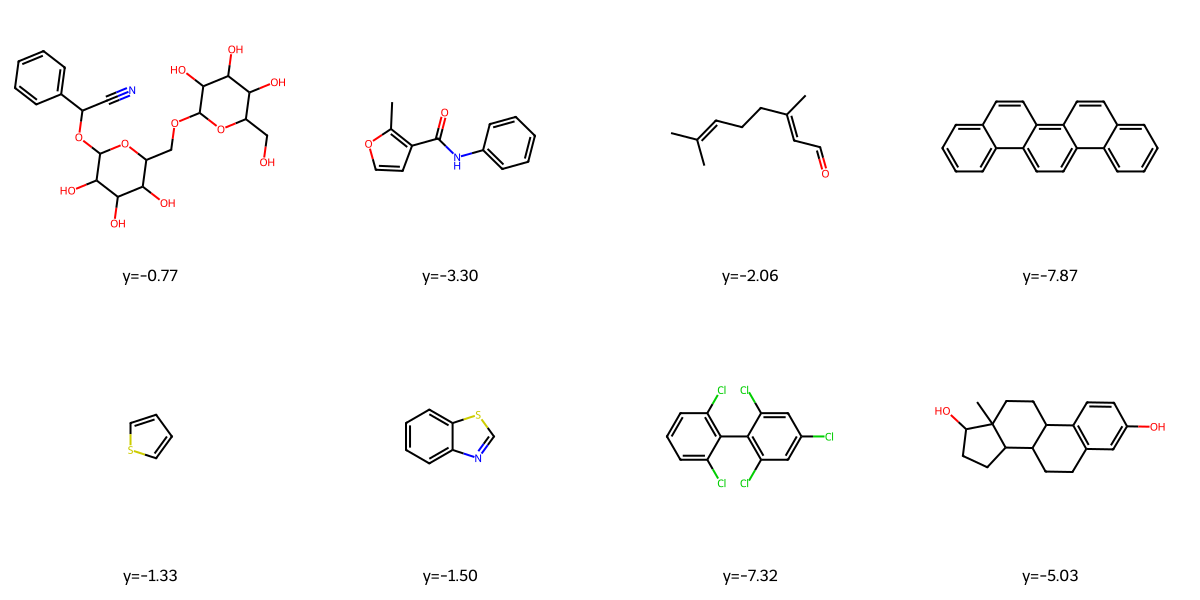

In [14]:
from rdkit import Chem
from rdkit.Chem import Draw

smiles_list = [data[i]["smiles"] for i in range(8)]
mols = [Chem.MolFromSmiles(s) for s in smiles_list]

img = Draw.MolsToGridImage(
    mols, molsPerRow=4,
    subImgSize=(300, 300),
    legends=[f"y={data[i].y.item():.2f}" for i in range(8)]
)
img

## 4 – Train / Test Split

Shuffle the dataset and use an 80/20 split.

In [15]:
from torch_geometric.loader import DataLoader

data = data.shuffle()

train_size = int(len(data) * 0.8)
train_dataset = data[:train_size]
test_dataset  = data[train_size:]

print(f"Training graphs : {len(train_dataset)}")
print(f"Test graphs     : {len(test_dataset)}")

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)

Training graphs : 902
Test graphs     : 226


## 5 – Build the Graph Neural Network

Three `GCNConv` layers let the model aggregate information from 3-hop neighbourhoods. A global mean-pool converts node embeddings into a single graph embedding, followed by a linear head that predicts the solubility value.

In [16]:
import torch.nn.functional as F
from torch.nn import Linear
from torch_geometric.nn import GCNConv, global_mean_pool


class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin   = Linear(hidden_channels, out_channels)

    def forward(self, x, edge_index, batch):
        h = self.conv1(x, edge_index)
        h = h.relu()
        h = self.conv2(h, edge_index)
        h = h.relu()
        h = self.conv3(h, edge_index)

        h = global_mean_pool(h, batch)

        h = F.dropout(h, p=0.5, training=self.training)
        h = self.lin(h)
        return h


model = GCN(
    in_channels=data.num_features,
    hidden_channels=64,
    out_channels=1
)
print(model)

GCN(
  (conv1): GCNConv(9, 64)
  (conv2): GCNConv(64, 64)
  (conv3): GCNConv(64, 64)
  (lin): Linear(in_features=64, out_features=1, bias=True)
)


## 6 – Train the GNN (1500 Epochs)

Use MSE loss (regression) with the Adam optimiser.

In [17]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.0007)
criterion = torch.nn.MSELoss()


def train_one_epoch():
    model.train()
    total_loss = 0
    for batch in train_loader:
        optimizer.zero_grad()
        out = model(batch.x.float(), batch.edge_index, batch.batch)
        loss = criterion(out.squeeze(), batch.y.float().squeeze())
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch.num_graphs
    return total_loss / len(train_loader.dataset)


EPOCHS = 1500
losses = []

for epoch in range(1, EPOCHS + 1):
    loss = train_one_epoch()
    losses.append(loss)
    if epoch % 100 == 0 or epoch == 1:
        print(f"Epoch {epoch:>5d} | Train MSE Loss: {loss:.4f}")

print("\nTraining complete.")

Epoch     1 | Train MSE Loss: 8.1021
Epoch   100 | Train MSE Loss: 1.8906
Epoch   200 | Train MSE Loss: 1.5279
Epoch   300 | Train MSE Loss: 1.4812
Epoch   400 | Train MSE Loss: 1.3770
Epoch   500 | Train MSE Loss: 1.3240
Epoch   600 | Train MSE Loss: 1.0921
Epoch   700 | Train MSE Loss: 1.1404
Epoch   800 | Train MSE Loss: 1.0227
Epoch   900 | Train MSE Loss: 0.8933
Epoch  1000 | Train MSE Loss: 0.8793
Epoch  1100 | Train MSE Loss: 0.8690
Epoch  1200 | Train MSE Loss: 0.9310
Epoch  1300 | Train MSE Loss: 0.8586
Epoch  1400 | Train MSE Loss: 0.8377
Epoch  1500 | Train MSE Loss: 0.7152

Training complete.


## 7 – Training Loss Curve

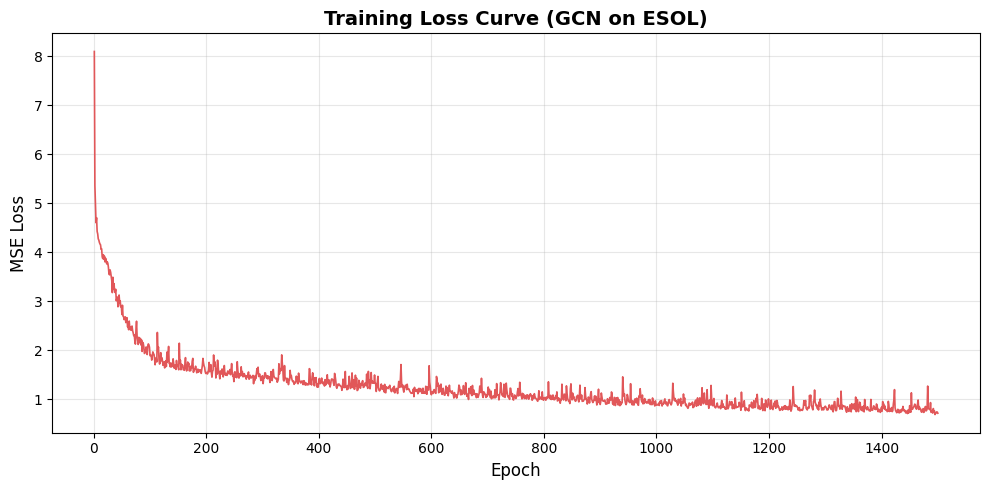

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(range(1, EPOCHS + 1), losses, color="#E15759", linewidth=1.2)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("MSE Loss", fontsize=12)
plt.title("Training Loss Curve (GCN on ESOL)", fontsize=14, fontweight="bold")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8 – Test Set Evaluation

In [19]:
import numpy as np


@torch.no_grad()
def evaluate(loader):
    model.eval()
    preds, targets = [], []
    for batch in loader:
        out = model(batch.x.float(), batch.edge_index, batch.batch)
        preds.append(out.squeeze().cpu())
        targets.append(batch.y.cpu())
    preds   = torch.cat(preds).numpy()
    targets = torch.cat(targets).numpy()
    mse  = np.mean((preds - targets) ** 2)
    rmse = np.sqrt(mse)
    mae  = np.mean(np.abs(preds - targets))
    return preds, targets, mse, rmse, mae


preds, targets, mse, rmse, mae = evaluate(test_loader)

print(f"Test MSE  : {mse:.4f}")
print(f"Test RMSE : {rmse:.4f}")
print(f"Test MAE  : {mae:.4f}")

Test MSE  : 9.5279
Test RMSE : 3.0867
Test MAE  : 2.4526


## 9 – Predicted vs Actual Scatter Plot

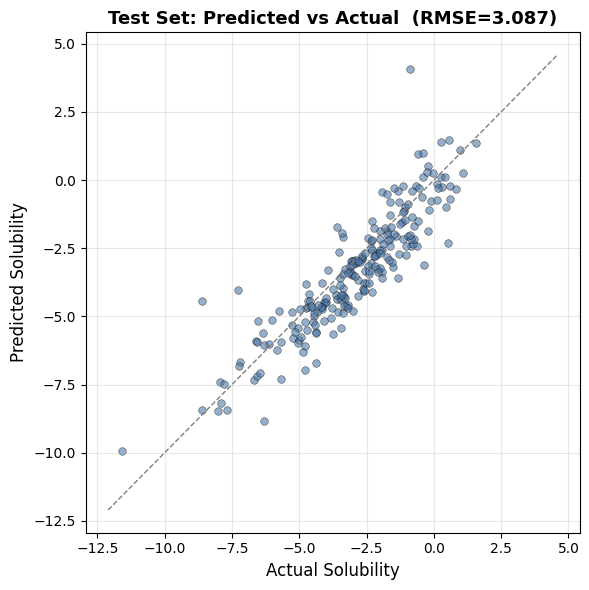

In [20]:
plt.figure(figsize=(6, 6))
plt.scatter(targets, preds, alpha=0.6, edgecolors="k", linewidths=0.4, s=30, color="#4E79A7")

lo = min(targets.min(), preds.min()) - 0.5
hi = max(targets.max(), preds.max()) + 0.5
plt.plot([lo, hi], [lo, hi], "--", color="gray", linewidth=1)

plt.xlabel("Actual Solubility", fontsize=12)
plt.ylabel("Predicted Solubility", fontsize=12)
plt.title(f"Test Set: Predicted vs Actual  (RMSE={rmse:.3f})",
          fontsize=13, fontweight="bold")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()